<a href="https://colab.research.google.com/github/windgodovo/agricultural-irrigation-prediction/blob/main/%E6%9C%BA%E5%99%A8%E5%AD%A6%E4%B9%A0_%E7%81%8C%E6%BA%89%E9%A2%84%E6%B5%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip -o /content/playground-series-s6e4.zip -d /content/playground-series-s6e4
!ls /content/playground-series-s6e4

Archive:  /content/playground-series-s6e4.zip
  inflating: /content/playground-series-s6e4/sample_submission.csv  
  inflating: /content/playground-series-s6e4/test.csv  
  inflating: /content/playground-series-s6e4/train.csv  
sample_submission.csv  test.csv  train.csv


In [2]:
import pandas as pd

train_df = pd.read_csv('/content/playground-series-s6e4/train.csv')
test_df = pd.read_csv('/content/playground-series-s6e4/test.csv')

print("训练集形状:", train_df.shape)
train_df.head()

训练集形状: (630000, 21)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

缺失值统计:


,0
id,0
Soil_Type,0
Soil_pH,0
Soil_Moisture,0
Organic_Carbon,0
Electrical_Conductivity,0
Temperature_C,0
Humidity,0
Rainfall_mm,0
Sunlight_Hours,0


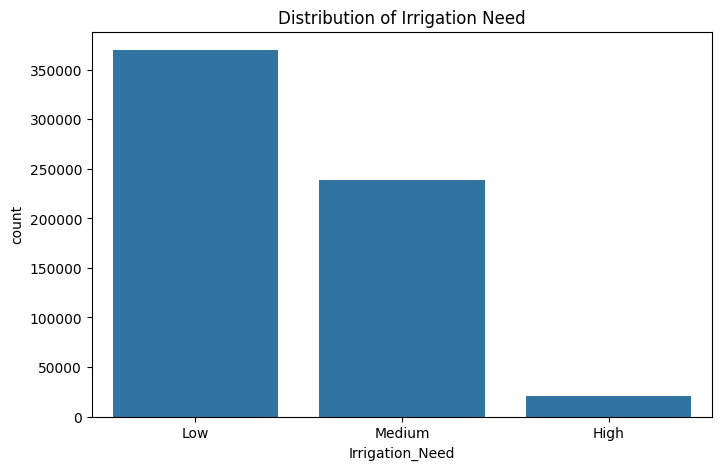


目标变量占比:
Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 检查缺失值
print("缺失值统计:")
display(train_df.isnull().sum())

# 检查目标变量分布
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='Irrigation_Need', order=['Low', 'Medium', 'High'])
plt.title('Distribution of Irrigation Need')
plt.show()

# 查看类别占比
print("\n目标变量占比:")
print(train_df['Irrigation_Need'].value_counts(normalize=True))

数值型特征与目标变量的相关性 (Pearson):
Irrigation_Need_Num        1.000000
Wind_Speed_kmh             0.258170
Temperature_C              0.252867
Previous_Irrigation_mm     0.019637
Field_Area_hectare         0.017699
Electrical_Conductivity    0.010785
Organic_Carbon             0.006451
Soil_pH                    0.000150
Sunlight_Hours            -0.000313
id                        -0.000903
Humidity                  -0.021870
Rainfall_mm               -0.111478
Soil_Moisture             -0.455482
Name: Irrigation_Need_Num, dtype: float64


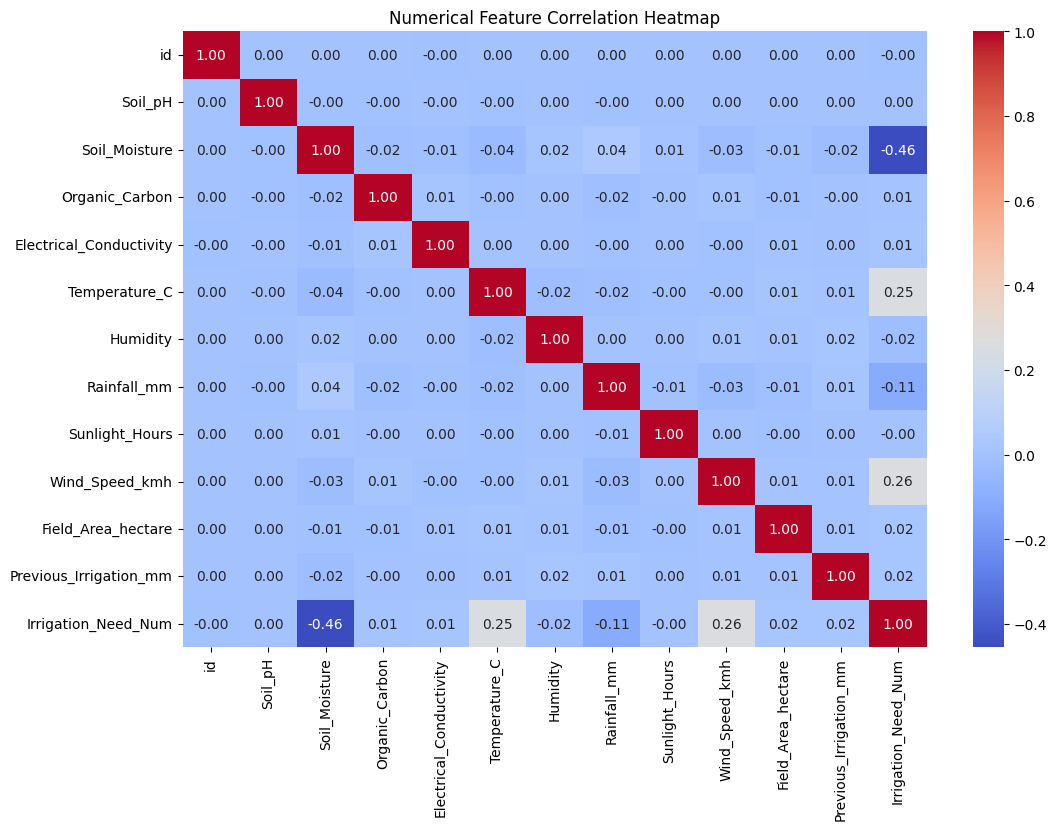

In [5]:
#相关性分析
import numpy as np

# 1. 将目标变量转换为数值以便计算相关性
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
train_df['Irrigation_Need_Num'] = train_df['Irrigation_Need'].map(target_map)

# 2. 数值型特征相关性
numerical_cols = train_df.select_dtypes(include=[np.number]).columns
corr_matrix = train_df[numerical_cols].corr()

print("数值型特征与目标变量的相关性 (Pearson):")
print(corr_matrix['Irrigation_Need_Num'].sort_values(ascending=False))

# 3. 可视化数值特征相关性热图
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

/tmp/ipykernel_12142/3318492110.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='Irrigation_Need', y='Soil_Moisture',
/tmp/ipykernel_12142/3318492110.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='Irrigation_Need', y='Wind_Speed_kmh',


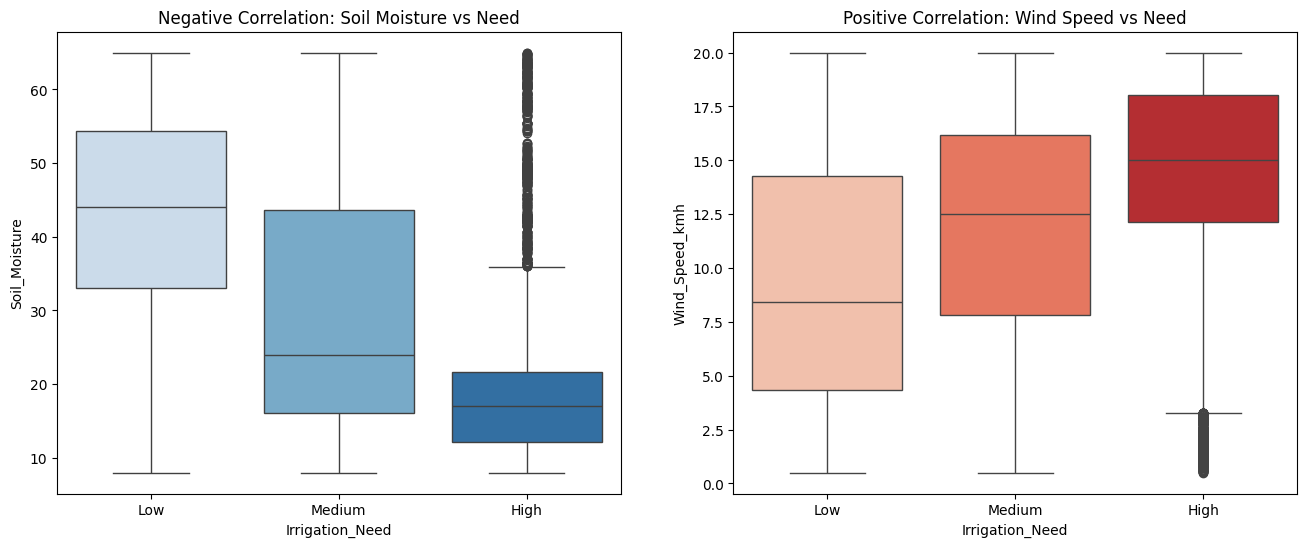

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 选取相关性最强的正负特征进行对比可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 负相关示例：土壤湿度 vs 灌溉需求
sns.boxplot(data=train_df, x='Irrigation_Need', y='Soil_Moisture',
            order=['Low', 'Medium', 'High'], ax=ax1, palette='Blues')
ax1.set_title('Negative Correlation: Soil Moisture vs Need')

# 正相关示例：风速 vs 灌溉需求
sns.boxplot(data=train_df, x='Irrigation_Need', y='Wind_Speed_kmh',
            order=['Low', 'Medium', 'High'], ax=ax2, palette='Reds')
ax2.set_title('Positive Correlation: Wind Speed vs Need')

plt.show()

可以很明显的看出Soil_Moisture-- 土壤湿度 与 灌溉需要是称负相关的，很好理解因为土壤湿度越高就越没有灌溉的必要；风速与灌溉需要是称正相关的，风速越快，作物水分挥发的越快，越需要灌溉

## 机器学习部分

### 建立逻辑回归基准模型

由于之前的基准测试代码已被移除，我们需要重新训练一个简单的逻辑回归模型，以便与 LightGBM 和神经网络进行性能对比。

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import pandas as pd # Added for data manipulation
from sklearn.preprocessing import LabelEncoder, StandardScaler # Added for preprocessing
from sklearn.model_selection import train_test_split # Added for data splitting

# --- Start of Data Preprocessing for Logistic Regression Baseline ---

# 1. Define categorical features
cat_features = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

# 2. Apply Label Encoding to categorical features in train_df
# Ensure train_df is in a state where original categorical columns are present
# (from after 'Irrigation_Need_Num' was added, but before any previous encoding)
le = LabelEncoder()
for col in cat_features:
    # Only encode if the column is of object type (not already encoded)
    if train_df[col].dtype == 'object':
        train_df[col] = le.fit_transform(train_df[col].astype(str))

# 3. Define feature matrix X_full and target y_full
X_full = train_df.drop(columns=['id', 'Irrigation_Need', 'Irrigation_Need_Num'])
y_full = train_df['Irrigation_Need_Num']

# 4. Stratified split (80/20) into training and validation sets
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

# 5. Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled = scaler.transform(X_val_full)

# --- End of Data Preprocessing for Logistic Regression Baseline ---

# 使用之前已经准备好的标准化数据 X_train_scaled, X_val_scaled
# 实例化逻辑回归模型
print("正在训练逻辑回归基准模型...")
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=42)

# 训练模型
lr_model.fit(X_train_scaled, y_train_full)

# 预测并计算指标
y_pred_lr = lr_model.predict(X_val_scaled)

# 定义全局变量以供后续对比单元格使用
accuracy = accuracy_score(y_val_full, y_pred_lr)
f1_macro = f1_score(y_val_full, y_pred_lr, average='macro')

print(f'Logistic Regression - Accuracy: {accuracy:.4f}')
print(f'Logistic Regression - Macro F1-score: {f1_macro:.4f}')

正在训练逻辑回归基准模型...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression - Accuracy: 0.6973
Logistic Regression - Macro F1-score: 0.6066


### LightGBM模型

#### LightGBM 模型选择理由与架构分析

在建立基线模型后，我们将转向更强大的梯度提升决策树（GBDT）框架：**LightGBM**。以下是针对本灌溉需求预测任务选择 LightGBM 的核心理由：

1.  **处理大规模数据的高效性**: 我们的训练集包含 630,000 条记录。LightGBM 通过基于直方图的决策树算法，显著降低了内存消耗并提升了训练速度。
2.  **非线性特征捕获**: 灌溉需求受土壤湿度、作物种类和气候（风速、降雨）等多种因素交叉影响。LightGBM 的 **Leaf-wise（带深度限制的叶子生长）策略** 能够发现比 Level-wise 生长更复杂的特征相互作用，从而获得更高的精度。
3.  **内建的类别特征处理**: 与逻辑回归需要显式 One-Hot 编码不同，LightGBM 可以直接通过特定的切分策略处理 Label Encoding 后的类别特征，避免了高维稀疏矩阵带来的维度灾难。
4.  **应对类别不平衡**: 数据集中 'High' 类别仅占约 3.3%。通过设置 `class_weight='balanced'`，LightGBM 会自动为少数类分配更高的损失权重，防止模型被占主导地位的 'Low' 类别带偏。



Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.0845125
[200]	valid_0's multi_logloss: 0.0733335
[300]	valid_0's multi_logloss: 0.0687484
[400]	valid_0's multi_logloss: 0.0659953
[500]	valid_0's multi_logloss: 0.0641388
[600]	valid_0's multi_logloss: 0.0628295
[700]	valid_0's multi_logloss: 0.0618008
[800]	valid_0's multi_logloss: 0.0610137
[900]	valid_0's multi_logloss: 0.0604129
[1000]	valid_0's multi_logloss: 0.0599579
Did not meet early stopping. Best iteration is:
[999]	valid_0's multi_logloss: 0.0599559

LightGBM Model - Accuracy: 0.9843
LightGBM Model - Macro F1-score: 0.9675

Classification Report:
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99     73983
      Medium       0.99      0.97      0.98     47815
        High       0.93      0.93      0.93      4202

    accuracy                           0.98    126000
   macro avg       0.97      0.97      0.97    126000
weighted avg  

<Figure size 1000x800 with 0 Axes>

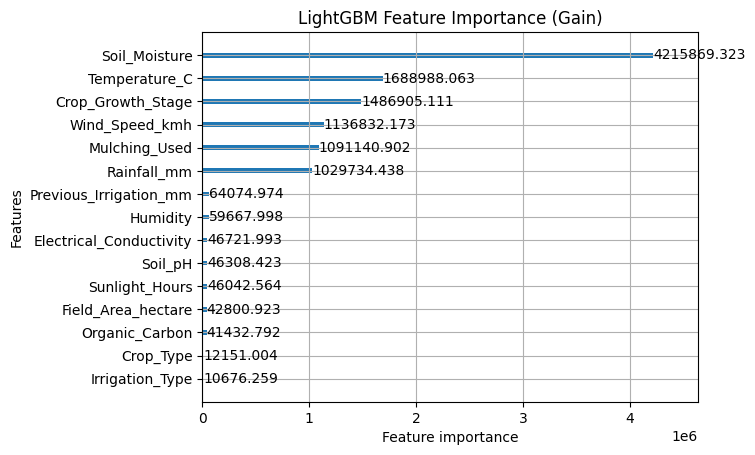

In [8]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# 1. & 2. Define categorical features for the full 630,000 records dataset
cat_features = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

# 3. Apply Label Encoding to categorical features in train_df
le = LabelEncoder()
for col in cat_features:
    train_df[col] = le.fit_transform(train_df[col].astype(str))

# 4. Define feature matrix X_full and target y_full
X_full = train_df.drop(columns=['id', 'Irrigation_Need', 'Irrigation_Need_Num'])
y_full = train_df['Irrigation_Need_Num']

# 5. Stratified split (80/20)
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

# 6. Instantiate LGBMClassifier with specified parameters
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced', #针对数据不平衡（High 仅占 3.3%）的关键设置，自动提升少数类的权重。
    importance_type='gain',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 7. Fit model with early stopping
lgb_model.fit(
    X_train_full, y_train_full,
    eval_set=[(X_val_full, y_val_full)],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# 8. Predict and evaluate
y_pred_lgb = lgb_model.predict(X_val_full)
accuracy_lgb = accuracy_score(y_val_full, y_pred_lgb)
f1_macro_lgb = f1_score(y_val_full, y_pred_lgb, average='macro')

print(f'\nLightGBM Model - Accuracy: {accuracy_lgb:.4f}')
print(f'LightGBM Model - Macro F1-score: {f1_macro_lgb:.4f}')
print('\nClassification Report:')
print(classification_report(y_val_full, y_pred_lgb, target_names=['Low', 'Medium', 'High']))

# 9. Visualize top 15 feature importance
plt.figure(figsize=(10, 8))
lgb.plot_importance(lgb_model, max_num_features=15, importance_type='gain', title='LightGBM Feature Importance (Gain)')
plt.show()

### 深度学习神经网络模型

In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# 1. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled = scaler.transform(X_val_full)

# 2. Compute class weights for 'balanced' handling
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_full),
    y=y_train_full
)
class_weight_dict = dict(enumerate(class_weights))

# 3 & 4. Build Functional API Architecture
input_layer = Input(shape=(X_train_scaled.shape[1],))

x = Dense(128, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

output_layer = Dense(3, activation='softmax')(x)

nn_model = Model(inputs=input_layer, outputs=output_layer)

# 5. Compile Model
nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# 6. Train the model
history = nn_model.fit(
    X_train_scaled, y_train_full,
    validation_data=(X_val_scaled, y_val_full),
    epochs=100,
    batch_size=1024,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

# 7. Evaluate and store metrics
y_pred_nn_probs = nn_model.predict(X_val_scaled)
y_pred_nn = np.argmax(y_pred_nn_probs, axis=1)

accuracy_nn = accuracy_score(y_val_full, y_pred_nn)
f1_macro_nn = f1_score(y_val_full, y_pred_nn, average='macro')

print(f'\nNeural Network - Accuracy: {accuracy_nn:.4f}')
print(f'Neural Network - Macro F1-score: {f1_macro_nn:.4f}')

Epoch 1/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.7384 - loss: 0.5594 - val_accuracy: 0.8832 - val_loss: 0.2839
Epoch 2/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8741 - loss: 0.3094 - val_accuracy: 0.9152 - val_loss: 0.2161
Epoch 3/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9015 - loss: 0.2547 - val_accuracy: 0.9282 - val_loss: 0.1925
Epoch 4/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9171 - loss: 0.2231 - val_accuracy: 0.9391 - val_loss: 0.1656
Epoch 5/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9281 - loss: 0.2018 - val_accuracy: 0.9486 - val_loss: 0.1457
Epoch 6/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9384 - loss: 0.1821 - val_accuracy: 0.9612 - val_loss: 0.1204
Epoch 7/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9448 - loss: 0.1700 - val_accuracy: 0.9657 - val_loss: 0.1108
Epoch 8/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9491 - loss: 0.1609 -

### 模型综合对比与冠军模型选拔



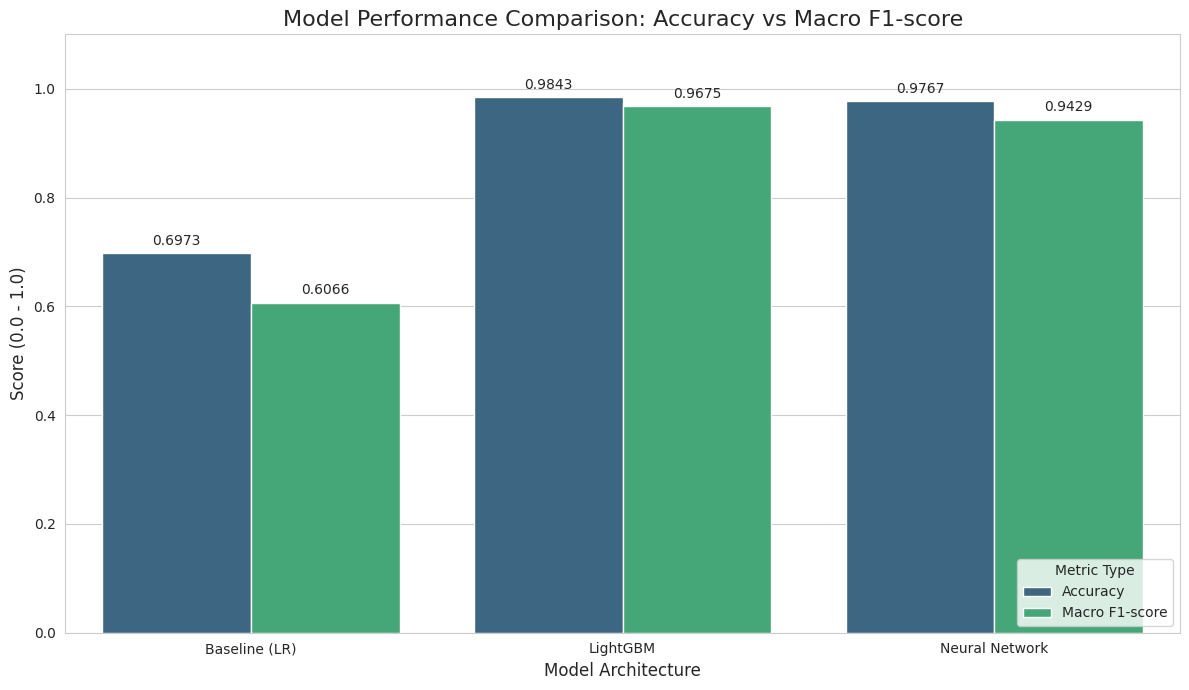

The Champion Model is: LightGBM with a Macro F1-score of 0.9675


In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. 使用刚才训练得到的真实基准指标
# accuracy 和 f1_macro 已在 cell 8d88caa6 中定义

comparison_data = {
    'Model': ['Baseline (LR)', 'LightGBM', 'Neural Network'],
    'Accuracy': [accuracy, accuracy_lgb, accuracy_nn],
    'Macro F1-score': [f1_macro, f1_macro_lgb, f1_macro_nn]
}
comparison_df = pd.DataFrame(comparison_data)

# 2. 转换格式进行绘图
plot_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 3. 创建可视化图表
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
bar_plot = sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='viridis')

# 设置 Y 轴范围
plt.ylim(0, 1.1)

# 4. 添加数值标签
for p in bar_plot.patches:
    if p.get_height() > 0:
        bar_plot.annotate(format(p.get_height(), '.4f'),
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points', fontsize=10)

plt.title('Model Performance Comparison: Accuracy vs Macro F1-score', fontsize=16)
plt.xlabel('Model Architecture', fontsize=12)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.legend(title='Metric Type', loc='lower right')
plt.tight_layout()
plt.show()

# 5. 选出冠军模型
best_idx = comparison_df['Macro F1-score'].idxmax()
champion_name = comparison_df.loc[best_idx, 'Model']
champion_score = comparison_df.loc[best_idx, 'Macro F1-score']
print(f"The Champion Model is: {champion_name} with a Macro F1-score of {champion_score:.4f}")

## 生成预测结果

### 预处理测试数据

### Subtask:
重新加载原始训练集和测试集，采用统一的标签编码策略和标准缩放，以确保测试数据与模型训练时的特征空间完全一致。


In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. 重新加载原始数据，确保拥有原始的类别字符串
train_raw = pd.read_csv('/content/playground-series-s6e4/train.csv')
test_raw = pd.read_csv('/content/playground-series-s6e4/test.csv')

# 2. 定义类别型特征列
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

# 3 & 4. 统一标签编码：在训练集和测试集的并集上进行拟合
train_df_processed = train_raw.copy()
test_df_processed = test_raw.copy()

for col in cat_cols:
    le = LabelEncoder()
    # 合并两个集合的值以处理测试集中可能出现的缺失标签（如 'Silt'）
    combined_values = pd.concat([train_raw[col], test_raw[col]]).astype(str)
    le.fit(combined_values)
    train_df_processed[col] = le.transform(train_raw[col].astype(str))
    test_df_processed[col] = le.transform(test_raw[col].astype(str))

# 5. 准备特征矩阵（删除非特征列）
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
train_df_processed['Irrigation_Need_Num'] = train_raw['Irrigation_Need'].map(target_map)

X_full_new = train_df_processed.drop(columns=['id', 'Irrigation_Need', 'Irrigation_Need_Num'])
X_test = test_df_processed.drop(columns=['id'])

# 6. 在全量训练特征上拟合 StandardScaler 并转换测试集
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full_new)
X_test_scaled = scaler.transform(X_test)

# 7. 验证步骤
columns_match = list(X_test.columns) == list(X_full_new.columns)
print(f'训练特征矩阵形状: {X_full_new.shape}')
print(f'测试特征矩阵形状: {X_test.shape}')
print(f'缩放后的测试矩阵形状: {X_test_scaled.shape}')
print(f'测试集列顺序是否与训练集一致? {columns_match}')
X_test.head()

训练特征矩阵形状: (630000, 19)
测试特征矩阵形状: (270000, 19)
缩放后的测试矩阵形状: (270000, 19)
测试集列顺序是否与训练集一致? True


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,3,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,1,2,1,0,3,13.59,1,47.48,4
1,0,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,0,2,1,1,2,6.12,1,56.43,3
2,2,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,5,2,0,3,2,3.11,1,20.00,1
3,0,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,1,1,1,0,0,2.27,0,102.99,2
4,1,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,0,2,0,0,0,12.39,1,13.33,0


### 生成预测结果

### Subtask:
使用表现最好的冠军模型 LightGBM 对预处理后的测试特征进行灌溉需求预测，并将数值结果映射回其原始字符串标签。


In [12]:
import numpy as np

# 1. Use the trained champion model (lgb_model) to predict on X_test
# Ensuring the feature order matches the training set X_full_new/X_train_full
y_test_pred_num = lgb_model.predict(X_test)

# 2. Create the inverse mapping dictionary
inverse_target_map = {0: 'Low', 1: 'Medium', 2: 'High'}

# 3. Convert numerical predictions to string labels
final_predictions = [inverse_target_map[val] for val in y_test_pred_num]

# 4. Verification and summary
print(f'Total predictions generated: {len(final_predictions)}')
print(f'Matches test set size (270,000)? {len(final_predictions) == 270000}')
print('\nFirst 10 predictions:')
for i in range(10):
    print(f'Index {i}: Numerical={y_test_pred_num[i]}, Label={final_predictions[i]}')

Total predictions generated: 270000
Matches test set size (270,000)? True

First 10 predictions:
Index 0: Numerical=0, Label=Low
Index 1: Numerical=0, Label=Low
Index 2: Numerical=0, Label=Low
Index 3: Numerical=0, Label=Low
Index 4: Numerical=0, Label=Low
Index 5: Numerical=1, Label=Medium
Index 6: Numerical=0, Label=Low
Index 7: Numerical=1, Label=Medium
Index 8: Numerical=1, Label=Medium
Index 9: Numerical=0, Label=Low


### 创建提交文件

### Subtask:
创建一个包含测试集 'id' 和预测标签 'Irrigation_Need' 的提交 DataFrame，并将其保存为 'submission.csv'。


In [13]:
import pandas as pd

# 1. Create the submission DataFrame using test IDs and final string predictions
submission_df = pd.DataFrame({
    'id': test_raw['id'],
    'Irrigation_Need': final_predictions
})

# 2. Save the DataFrame to 'submission.csv' without row indices
submission_df.to_csv('submission.csv', index=False)

# 3. Print the first few rows to verify the format
print("Submission file successfully created!")
print(submission_df.head())

# Extra check for the length
print(f"\nTotal rows in submission: {len(submission_df)}")

Submission file successfully created!
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low

Total rows in submission: 270000


## 进一步的调优

### 超参数优化

In [19]:
!pip install optuna

In [15]:
import optuna
import lightgbm as lgb
from sklearn.metrics import f1_score

def objective(trial):
    param = {
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'multi_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1)
    }

    # 使用较小的数据子集进行快速搜索
    idx = np.random.choice(len(X_train_full), 100000, replace=False)
    X_sub = X_train_full.iloc[idx]
    y_sub = y_train_full.iloc[idx]

    gbm = lgb.LGBMClassifier(**param, n_estimators=100, class_weight='balanced', random_state=42)
    gbm.fit(X_sub, y_sub)
    preds = gbm.predict(X_val_full)
    return f1_score(y_val_full, preds, average='macro')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print('Best trial:', study.best_trial.params)

[I 2026-04-09 09:37:07,570] A new study created in memory with name: no-name-63546b80-8704-4680-a3fc-e7d2d8dee201
[I 2026-04-09 09:37:38,236] Trial 0 finished with value: 0.9456190476895768 and parameters: {'lambda_l1': 3.054160267819224e-06, 'lambda_l2': 0.00915668269367656, 'num_leaves': 124, 'feature_fraction': 0.8487007601300411, 'bagging_fraction': 0.9545952498302257, 'bagging_freq': 1, 'min_child_samples': 69, 'learning_rate': 0.011894731933448208}. Best is trial 0 with value: 0.9456190476895768.
[I 2026-04-09 09:38:05,810] Trial 1 finished with value: 0.9473100437791274 and parameters: {'lambda_l1': 4.0303955432171364e-05, 'lambda_l2': 1.0023022597912259e-07, 'num_leaves': 229, 'feature_fraction': 0.48894597760903225, 'bagging_fraction': 0.5094161041264765, 'bagging_freq': 2, 'min_child_samples': 66, 'learning_rate': 0.03499520306980092}. Best is trial 1 with value: 0.9473100437791274.
[I 2026-04-09 09:38:19,055] Trial 2 finished with value: 0.9594180014714703 and parameters: {'

Best trial: {'lambda_l1': 0.0006211403976457924, 'lambda_l2': 1.2872708930206754e-05, 'num_leaves': 163, 'feature_fraction': 0.7395679429479303, 'bagging_fraction': 0.883558429113907, 'bagging_freq': 5, 'min_child_samples': 19, 'learning_rate': 0.08605639500860003}


### 使用全量数据和最佳参数重训模型
我们将不再进行训练/验证分割，而是直接在所有 630,000 条记录上应用最佳超参数进行训练，以获得最终的生产模型。

In [18]:
import lightgbm as lgb
import pandas as pd

# 1. 获取 Optuna 的最佳参数并更新配置
best_params = study.best_trial.params
best_params.update({
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1
})

# 2. 准备全量训练特征和标签
X_all = pd.concat([X_train_full, X_val_full])
y_all = pd.concat([y_train_full, y_val_full])

# 3. 实例化最终模型
# 注意：在全量训练时，我们使用之前确定的最佳迭代次数（例如 1000 左右）
final_model_full = lgb.LGBMClassifier(
    n_estimators=1000,
    **best_params,
    class_weight='balanced'
)

# 4. 在全量数据上拟合
print("正在全量数据上训练最终模型...")
final_model_full.fit(X_all, y_all)

# 5. 对测试集进行预测
y_test_final_num = final_model_full.predict(X_test)

# 6. 还原为字符串标签
inverse_map = {0: 'Low', 1: 'Medium', 2: 'High'}
final_labels = [inverse_map[val] for val in y_test_final_num]

# 7. 保存最终提交文件
final_submission = pd.DataFrame({
    'id': test_raw['id'],
    'Irrigation_Need': final_labels
})

final_submission.to_csv('submission_optimized.csv', index=False)
print("最终优化后的提交文件已保存为: submission_optimized.csv")
display(final_submission.head())

正在全量数据上训练最终模型...
最终优化后的提交文件已保存为: submission_optimized.csv


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


### 进一步优化建议：
1. **交叉验证 (K-Fold)**：目前我们使用的是单次验证集分割。使用 5 折或 10 折交叉验证可以更稳健地评估模型性能。
2. **特征工程**：虽然模型已经很强，但尝试创建一些交互特征（例如：`Soil_Moisture` / `Temperature_C`）可能会带来意外的提升。
3. **加权集成**：如果神经网络和逻辑回归在某些样本上表现更好，可以尝试将它们的结果按权重融合：`Final = 0.7 * LGBM + 0.2 * NN + 0.1 * LR`。